# Notebook 03 — Feature Analysis

## Feature Analysis Setup

This section initialises the environment for feature analysis by importing the required libraries and loading project configuration parameters. The selected libraries support statistical analysis, feature extraction, and basic modelling, enabling deeper investigation of relationships between features and the target variable.

Configuration variables are loaded from a central module to ensure consistency across experiments, including dataset paths, linguistic cue lists, and reproducibility settings. This modular approach improves maintainability and allows easy adjustments without modifying core code.

Additionally, plotting aesthetics are standardised for consistency across visualisations, and a dedicated directory is created to store feature analysis outputs. A predefined colour palette is also set for consistent representation of class labels.

In [ ]:
# System path setup
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import LabelEncoder

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Project configuration
import config
from config import (
    LABELLED_DATASET,  
    PLOTS_DIR,         
    NEGATION_CUES,     
    INTENSIFIERS,      
    RANDOM_STATE,      
)

# Create directory for feature analysis outputs
os.makedirs(PLOTS_DIR / 'feature_analysis', exist_ok=True)

# Global plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Class-wise colour palette
PALETTE = {
    'suicide': '#E63946',
    'non-suicide': '#457B9D'
}

print('Ready.')

Ready.


## Loading Processed Dataset

This section loads the preprocessed dataset containing all splits and separates it into training, validation, and test subsets based on the split identifier. This approach ensures consistency with earlier preprocessing steps and avoids redundant data splitting.

Each subset is stored independently to facilitate downstream analysis and model development. The sizes of the splits are displayed to confirm correct loading and partitioning.

In [2]:
# Load processed dataset
df = pd.read_csv(LABELLED_DATASET)

# Split into train, validation, and test sets
train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'val'].copy()
test  = df[df['split'] == 'test'].copy()

# Display split sizes
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

Train: 92,714  Val: 92,715  Test: 46,358


## TF-IDF Feature Extraction

This section converts the cleaned text into numerical features using the TF-IDF (Term Frequency–Inverse Document Frequency) representation. TF-IDF captures the importance of words and phrases by balancing their frequency within a document against their rarity across the corpus.

The vectoriser is fitted only on the training data to avoid data leakage. Both unigrams and bigrams are included to capture individual terms as well as short contextual phrases. Additional parameters such as minimum document frequency and sublinear term scaling help reduce noise and improve feature quality.

The resulting sparse matrix represents each document in a high-dimensional feature space, ready for modelling and further analysis.

In [3]:
# Fit TF-IDF on training text
tfidf = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5
)

# Transform training data
X_train_tfidf = tfidf.fit_transform(train['text_clean'])
y_train = train['label_id'].values

# Display matrix shape
print(f'TF-IDF matrix: {X_train_tfidf.shape}')

TF-IDF matrix: (92714, 20000)


## Feature Importance via Logistic Regression

This section uses logistic regression coefficients as a proxy for feature importance. After training a linear model on TF-IDF features, the learned coefficients indicate how strongly each term contributes to predicting a particular class.

Positive coefficients are associated with the suicide class, while negative coefficients correspond to the non-suicide class. By ranking these coefficients, the most influential words and phrases for each class can be identified.

This analysis provides interpretable insights into which linguistic patterns are most discriminative in the dataset.

In [4]:
# Train logistic regression model
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr.fit(X_train_tfidf, y_train)

# Extract feature names and coefficients
feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

# Identify top features for each class
top_k = 20

top_suicide_idx = coefs.argsort()[-top_k:][::-1]
top_nonsuicide_idx = coefs.argsort()[:top_k]

top_suicide = pd.DataFrame({
    'feature': feature_names[top_suicide_idx],
    'coefficient': coefs[top_suicide_idx]
})

top_nonsuicide = pd.DataFrame({
    'feature': feature_names[top_nonsuicide_idx],
    'coefficient': coefs[top_nonsuicide_idx]
})

# Display top features
print('Top 10 features → Suicide class:')
print(top_suicide.head(10).to_string(index=False))
print()

print('Top 10 features → Non-Suicide class:')
print(top_nonsuicide.head(10).to_string(index=False))

Top 10 features → Suicide class:
 feature  coefficient
 suicide    15.568344
suicidal    13.215028
    life     8.324243
  myself     7.947936
    kill     7.723477
     die     7.042820
   pills     7.027470
     end     5.715763
 killing     5.302706
thoughts     4.959138

Top 10 features → Non-Suicide class:
  feature  coefficient
    bored    -4.978875
   school    -4.832082
teenagers    -4.738735
    crush    -4.695170
    horny    -4.684277
       we    -4.259871
     like    -4.205288
       dm    -4.103867
     guys    -4.078543
minecraft    -4.018058


## TF-IDF Feature Importance Visualisation

This section visualises the most influential TF-IDF features for each class based on the absolute magnitude of logistic regression coefficients. The magnitude reflects the strength of association between a feature and the target class, regardless of direction.

Horizontal bar charts are used to display the top features for both classes, enabling an intuitive comparison of the most discriminative terms and phrases. This visualisation complements the numerical analysis and enhances interpretability of the model.

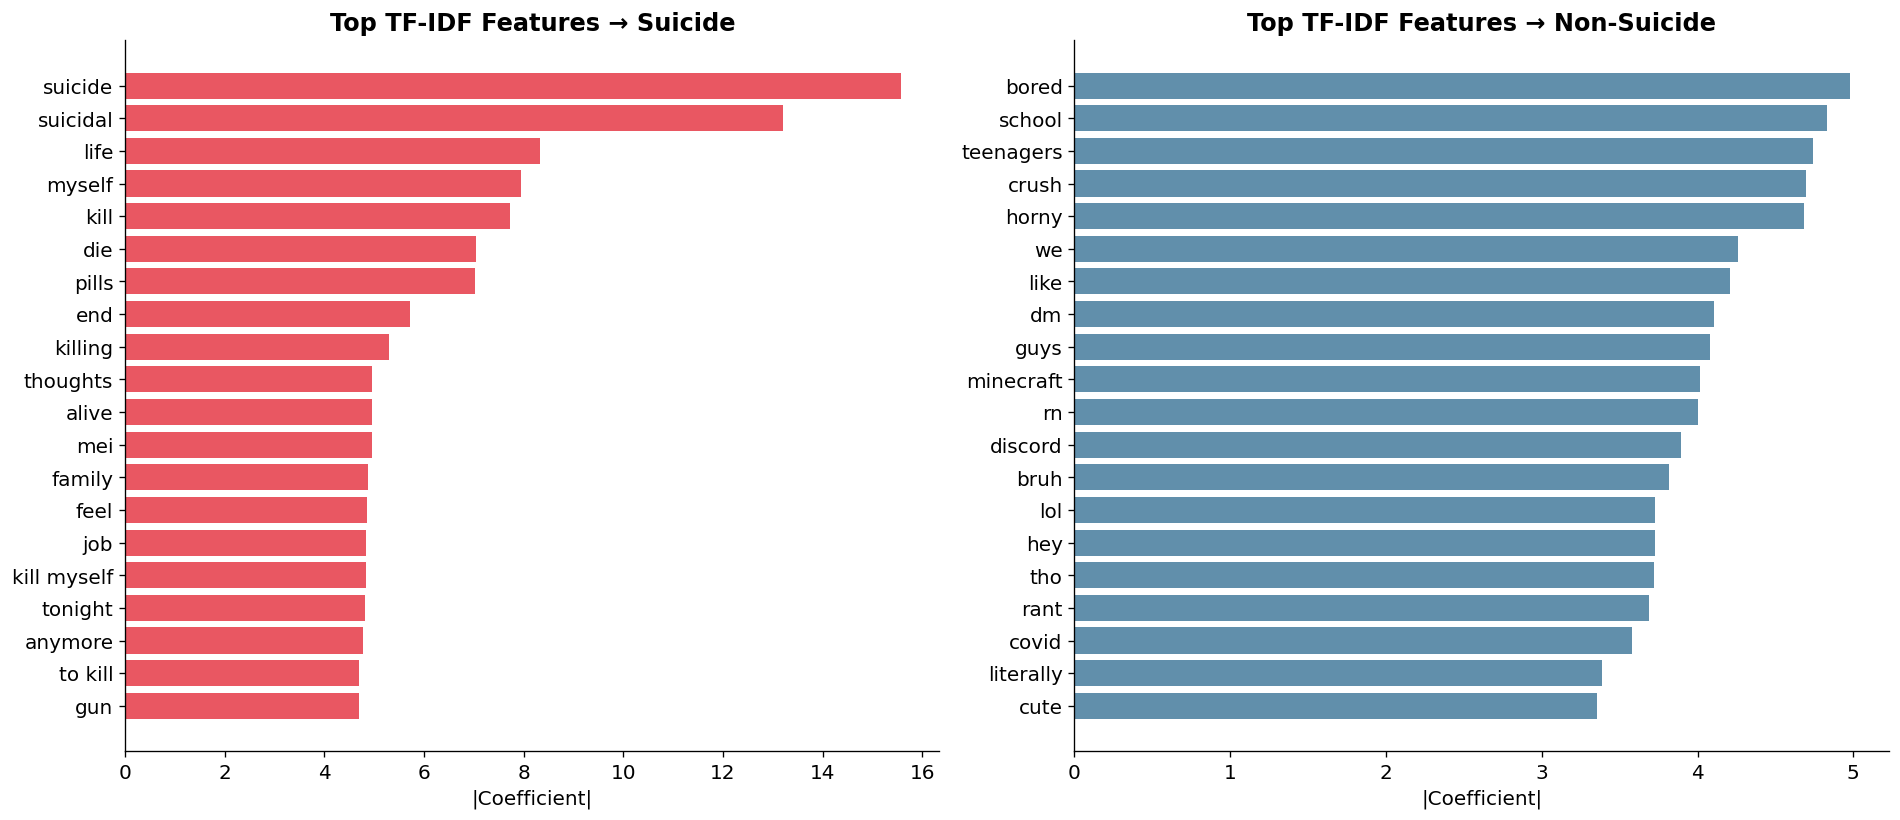

In [5]:
# Visualise top TF-IDF feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title, color in zip(
    axes,
    [top_suicide, top_nonsuicide],
    ['Top TF-IDF Features → Suicide', 'Top TF-IDF Features → Non-Suicide'],
    ['#E63946', '#457B9D']
):
    ax.barh(
        data['feature'][::-1],
        data['coefficient'].abs()[::-1],
        color=color,
        alpha=0.85
    )
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('|Coefficient|')

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_analysis' / 'tfidf_feature_importance.png', bbox_inches='tight')
plt.show()

## Statistical Significance Testing

This section evaluates whether key features differ significantly between classes using the Mann–Whitney U test, a non-parametric test suitable for comparing distributions without assuming normality.

The test is applied to features such as negation ratio, intensifier ratio, and word count. A low p-value (typically < 0.05) indicates that the difference between the two groups is statistically significant, suggesting that the feature may be informative for classification.

In [6]:
# Mann-Whitney U test for selected features
for feat in ['neg_ratio', 'intens_ratio', 'word_count']:
    if feat not in train.columns:
        continue

    group_s = train[train['label'] == 'suicide'][feat].dropna()
    group_ns = train[train['label'] == 'non-suicide'][feat].dropna()

    stat, p = stats.mannwhitneyu(group_s, group_ns, alternative='two-sided')

    print(f'{feat:20s}  |  U={stat:.0f}  |  p={p:.4e}  |  Significant: {p < 0.05}')

## Linguistic Feature Distribution Visualisation

This section visualises the distribution of key linguistic features using violin plots. These plots combine the properties of box plots and kernel density estimation, providing insights into both the distribution shape and summary statistics.

Features such as negation ratio, intensifier ratio, and intensifier score are analysed across classes. To reduce the impact of extreme outliers and improve interpretability, values are clipped at the 97th percentile before plotting.

This visualisation helps identify differences in feature distributions and supports earlier statistical findings.

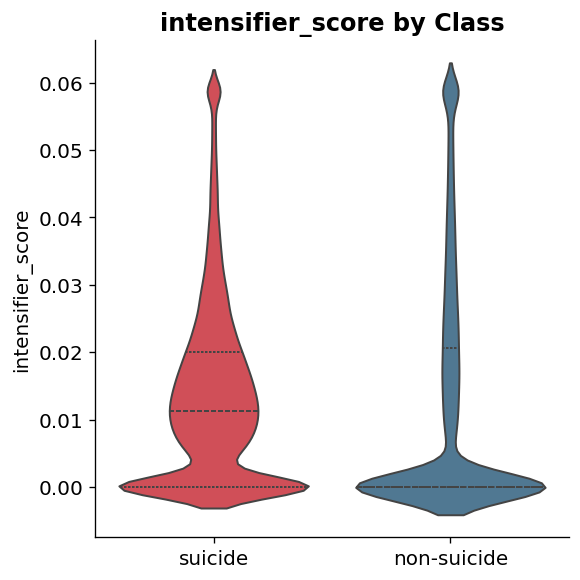

In [7]:
# Violin plots for linguistic features
features_to_plot = [c for c in ['neg_ratio', 'intens_ratio', 'intensifier_score']
                    if c in train.columns]

if features_to_plot:
    fig, axes = plt.subplots(1, len(features_to_plot), figsize=(5*len(features_to_plot), 5))
    
    if len(features_to_plot) == 1:
        axes = [axes]

    for ax, feat in zip(axes, features_to_plot):
        plot_df = train[['label', feat]].copy()
        plot_df[feat] = plot_df[feat].clip(upper=plot_df[feat].quantile(0.97))

        sns.violinplot(
            data=plot_df,
            x='label',
            y=feat,
            ax=ax,
            palette=PALETTE,
            inner='quartile',
            linewidth=1.2
        )

        ax.set_title(f'{feat} by Class', fontweight='bold')
        ax.set_xlabel('')

    # Adjust layout and save figure
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'feature_analysis' / 'linguistic_violins.png', bbox_inches='tight')
    plt.show()

## Negation Cue Frequency Analysis

This section examines how frequently predefined negation cues occur across the two classes. The goal is to identify which negation words are more strongly associated with the suicide class compared to the non-suicide class.

A frequency count is computed for each negation cue within each class. These counts are then combined into a single table, and a smoothed ratio is calculated to measure how skewed each cue is toward the suicide class. Adding 1 to both numerator and denominator ensures numerical stability and avoids division by zero.

The cues are sorted in descending order of this ratio, highlighting the most discriminative negation signals that may contribute to downstream classification performance.

In [8]:
from collections import Counter

def cue_frequency(df_subset, cue_list):
    counter = Counter()
    for text in df_subset['text_clean']:
        tokens = str(text).split()
        for t in tokens:
            if t in cue_list:
                counter[t] += 1
    return counter

neg_suicide    = cue_frequency(train[train['label'] == 'suicide'], NEGATION_CUES)
neg_nonsuicide = cue_frequency(train[train['label'] == 'non-suicide'], NEGATION_CUES)

neg_df = pd.DataFrame({
    'cue': list(set(neg_suicide.keys()) | set(neg_nonsuicide.keys()))
})

neg_df['suicide_freq']    = neg_df['cue'].map(neg_suicide).fillna(0)
neg_df['nonsuicide_freq'] = neg_df['cue'].map(neg_nonsuicide).fillna(0)

neg_df['ratio'] = (neg_df['suicide_freq'] + 1) / (neg_df['nonsuicide_freq'] + 1)

neg_df = neg_df.sort_values('ratio', ascending=False).reset_index(drop=True)

print('Negation cues most skewed toward suicide class:')
print(neg_df.head(10).to_string(index=False))

Negation cues most skewed toward suicide class:
     cue  suicide_freq  nonsuicide_freq     ratio
   can't         22436             2169 10.339631
  cannot          2264              284  7.947368
 nowhere           594               74  7.933333
wouldn't          2813              362  7.752066
   don't         46607             6336  7.354900
couldn't          2936              402  7.287841
   won't          4637              641  7.224299
 nothing         11426             1606  7.110765
  hasn't           681              101  6.686275
  nobody          3504              532  6.575985


## Negation Cue Frequency Comparison

This section visualises the frequency of the most discriminative negation cues across the two classes. The top cues are selected based on their skew toward the suicide class, as computed in the previous step.

A grouped bar chart is used to compare the frequency of each cue in both classes side by side. This allows for a direct inspection of which negation terms are more prevalent in one class versus the other.

Such patterns can provide useful linguistic insights and help validate whether negation-based features contribute meaningfully to classification performance.

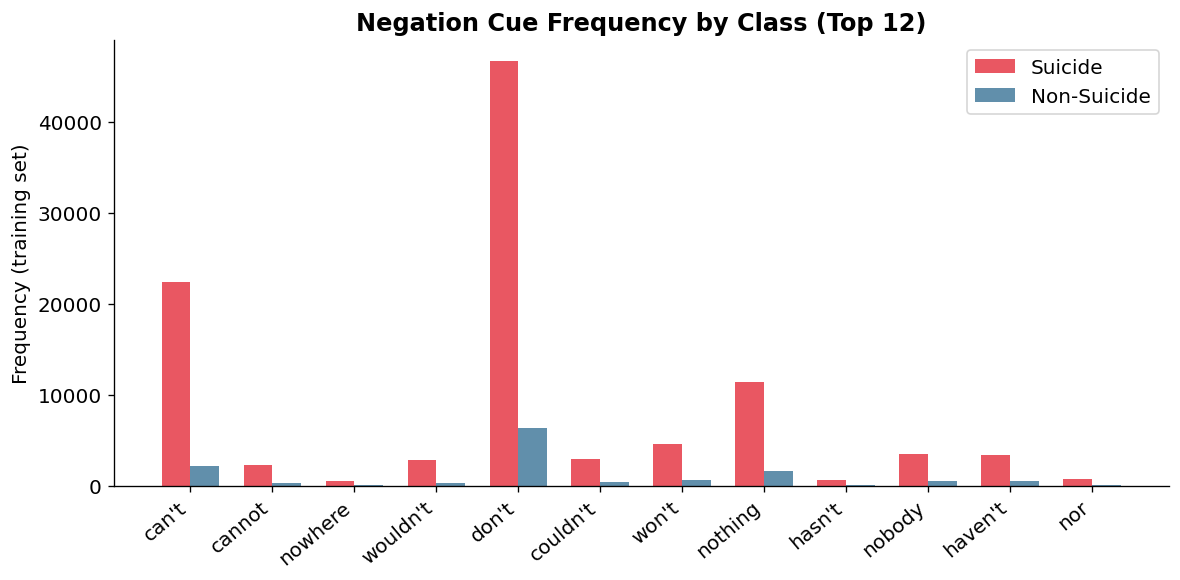

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

top_cues = neg_df.head(12)
x = np.arange(len(top_cues))
width = 0.35

ax.bar(
    x - width/2,
    top_cues['suicide_freq'],
    width,
    label='Suicide',
    color='#E63946',
    alpha=0.85
)

ax.bar(
    x + width/2,
    top_cues['nonsuicide_freq'],
    width,
    label='Non-Suicide',
    color='#457B9D',
    alpha=0.85
)

ax.set_xticks(x)
ax.set_xticklabels(top_cues['cue'], rotation=40, ha='right')

ax.set_ylabel('Frequency (training set)')
ax.set_title('Negation Cue Frequency by Class (Top 12)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_analysis' / 'negation_cue_frequency.png', bbox_inches='tight')
plt.show()

## Intensifier Usage Analysis

This section analyses how intensifier words are distributed across classes using a log-ratio metric. Intensifiers (e.g., *very*, *extremely*, *really*) reflect emotional amplification and can provide valuable signals in distinguishing between classes.

For each intensifier, frequencies are computed separately for the suicide and non-suicide classes. These frequencies are normalised by class size to obtain comparable proportions. A log₂ ratio is then calculated to quantify the relative association of each word with the suicide class.

Positive log-ratio values indicate higher prevalence in the suicide class, while negative values indicate higher prevalence in the non-suicide class. The horizontal bar chart highlights these differences, with colour coding used to distinguish directional association.

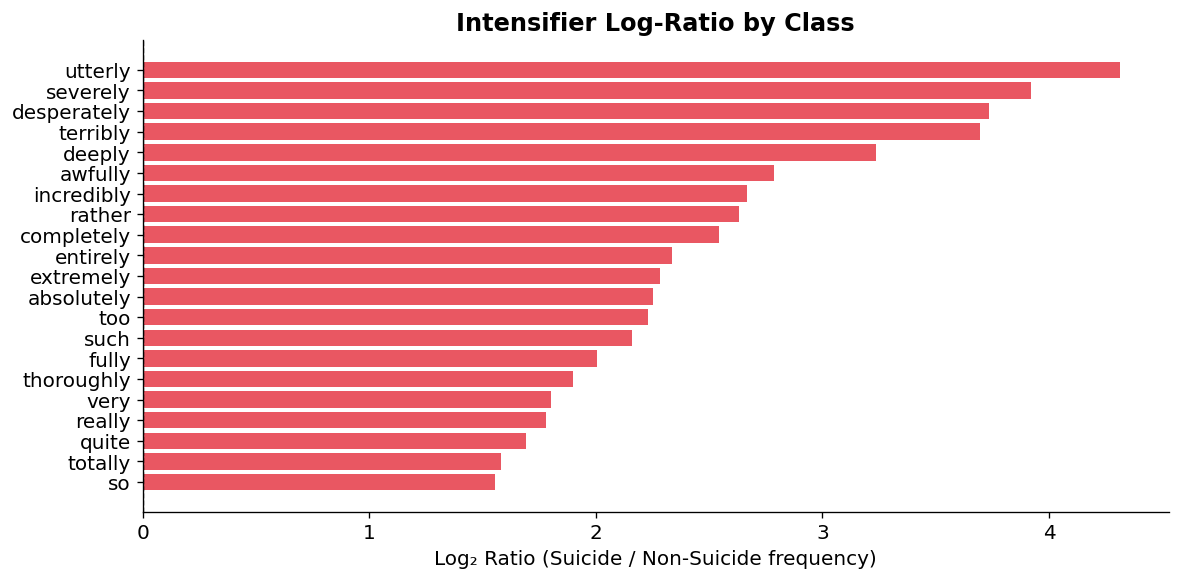

In [ ]:
int_suicide    = cue_frequency(train[train['label'] == 'suicide'], INTENSIFIERS)
int_nonsuicide = cue_frequency(train[train['label'] == 'non-suicide'], INTENSIFIERS)

int_df = pd.DataFrame({'word': INTENSIFIERS})

int_df['suicide_freq']    = int_df['word'].map(int_suicide).fillna(0)
int_df['nonsuicide_freq'] = int_df['word'].map(int_nonsuicide).fillna(0)

int_df['suicide_pct']    = int_df['suicide_freq'] / len(train[train['label'] == 'suicide'])
int_df['nonsuicide_pct'] = int_df['nonsuicide_freq'] / len(train[train['label'] == 'non-suicide'])

# Compute log-ratio
int_df['log_ratio'] = np.log2(
    (int_df['suicide_pct'] + 1e-6) / (int_df['nonsuicide_pct'] + 1e-6)
)

# Sort by importance
int_df = int_df.sort_values('log_ratio', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E63946' if r > 0 else '#457B9D' for r in int_df['log_ratio']]

ax.barh(
    int_df['word'][::-1],
    int_df['log_ratio'][::-1],
    color=colors[::-1],
    alpha=0.85
)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_xlabel('Log₂ Ratio (Suicide / Non-Suicide frequency)')
ax.set_title('Intensifier Log-Ratio by Class', fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_analysis' / 'intensifier_log_ratio.png', bbox_inches='tight')
plt.show()